In [2]:
import matplotlib.pyplot as plt
import anndata as ad
import gc
import numpy as np
import pandas as pd
import pingouin as pg
import scanpy as sc
from scipy import stats
import scipy.sparse as sp
import seaborn as sns


from collections import defaultdict
from pathlib import Path
from scipy.stats import wilcoxon, ttest_rel, rankdata

from analysis_lincs import load_test_results, control_baseline_metrics, mean_baseline_metrics, technical_duplicate_metrics, prnet_evaluation_metrics

from models.simple_baselines import control_baseline, mean_baseline, technical_duplicate_baseline

#### Load Expression Data

In [3]:
expression_data_dir = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_00/intermediates/preprocessed_dataset.h5ad")
expression_data_dir2 = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_01/intermediates/updated_dataset.h5ad")

adata = sc.read_h5ad(expression_data_dir)
adata2 = sc.read_h5ad(expression_data_dir2) # adata2: Run with embedding method map4c

In [4]:
results_data_dir1 = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_00/evaluation")
results_data_dir1.mkdir(parents=True, exist_ok=True)

In [5]:
results_data_dir2 = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_01/evaluation")
results_data_dir2.mkdir(parents=True, exist_ok=True)

In [6]:
adata2.obs.index = adata.obs.index

In [7]:
obs = adata.obs
records = []

for fold in range(5):
    split_col = f'canonical_smiles_split_{fold}'
    train = obs[obs[split_col] == 'train']
    test  = obs[obs[split_col] == 'test']

    train_fps = set(train['fingerprint_smiles'].dropna()) - {'CONTROL'}
    test_fps  = set(test['fingerprint_smiles'].dropna()) - {'CONTROL'}
    leaked_fps = train_fps & test_fps

    test_leaked_mask = test['fingerprint_smiles'].isin(leaked_fps)
    test_leaked_count = test_leaked_mask.sum()
    leaked_smiles = sorted(test.loc[test_leaked_mask, 'canonical_smiles'].unique())

    if leaked_fps:
        print(f"Fold {fold}: LEAKAGE DETECTED ({len(leaked_fps)} fps | {test_leaked_count} test samples leaked from train)")
    else:
        print(f"Fold {fold}: No leakage detected.")

    records.append({
        'fold': fold,
        'num_leaked_fps': len(leaked_fps),
        'num_leaked_test_samples': test_leaked_count,
        'leaked_canonical_smiles': "; ".join(leaked_smiles),
    })

pd.DataFrame(records).to_csv("fingerprint_leakage_smiles_split.csv", index=False)

Fold 0: LEAKAGE DETECTED (1236 fps | 38338 test samples leaked from train)
Fold 1: LEAKAGE DETECTED (1211 fps | 34577 test samples leaked from train)
Fold 2: LEAKAGE DETECTED (1215 fps | 33064 test samples leaked from train)
Fold 3: LEAKAGE DETECTED (1185 fps | 34840 test samples leaked from train)
Fold 4: LEAKAGE DETECTED (1192 fps | 35771 test samples leaked from train)


In [8]:
obs = adata2.obs
records = []

for fold in range(5):
    # 1. Isolate train and test splits for the current fold
    split_col = f'canonical_smiles_split_{fold}'
    train = obs[obs[split_col] == 'train']
    test  = obs[obs[split_col] == 'test']

    # 2. Find overlapping fingerprints (excluding control placeholders)
    train_fps = set(train['fingerprint_smiles'].dropna()) - {'CONTROL'}
    test_fps  = set(test['fingerprint_smiles'].dropna()) - {'CONTROL'}
    leaked_fps = train_fps & test_fps

    # 3. Count test set samples carrying leaked fingerprints & extract SMILES
    test_leaked_mask = test['fingerprint_smiles'].isin(leaked_fps)
    test_leaked_count = test_leaked_mask.sum()
    leaked_smiles = sorted(test.loc[test_leaked_mask, 'canonical_smiles'].unique())

    # 4. Output results
    if leaked_fps:
        print(f"Fold {fold}: LEAKAGE DETECTED ({len(leaked_fps)} fps | {test_leaked_count} test samples leaked from train)")
    else:
        print(f"Fold {fold}: No leakage detected.")

    records.append({
        'fold': fold,
        'num_leaked_fps': len(leaked_fps),
        'num_leaked_test_samples': test_leaked_count,
        'leaked_canonical_smiles': "; ".join(leaked_smiles),
    })

pd.DataFrame(records).to_csv("fingerprint_leakage_smiles_split.csv", index=False)

Fold 0: LEAKAGE DETECTED (15 fps | 2602 test samples leaked from train)
Fold 1: LEAKAGE DETECTED (13 fps | 1004 test samples leaked from train)
Fold 2: LEAKAGE DETECTED (12 fps | 1246 test samples leaked from train)
Fold 3: LEAKAGE DETECTED (9 fps | 965 test samples leaked from train)
Fold 4: LEAKAGE DETECTED (14 fps | 1716 test samples leaked from train)


In [9]:
def filter_adata(adata: ad.AnnData, split_axis: str):
    test_cell_lines = {}
    cell_lines = []

    for fold in range(5):
        test = adata.obs[f'{split_axis}_split_{fold}'] == 'test'

        cell_lines = adata.obs.loc[test, 'cell_type'].unique().tolist()
        
        test_cell_lines[fold] = cell_lines
        
        gc.collect()
    return test_cell_lines


In [10]:
test_cell_lines_smiles = filter_adata(adata=adata, split_axis='canonical_smiles')
test_cell_lines_map4c  = filter_adata(adata=adata2, split_axis='canonical_smiles')

#### Simple Baselines

In [11]:
# Setup Paths for baselines
control_baseline_path = Path(results_data_dir1 / "control_expression_profile.parquet")
control_baseline_map4c_path = Path(results_data_dir2 / "control_expression_profile_map4c.parquet")

mean_baseline_smiles_path = Path(results_data_dir1 / "mean_expression_profile_smiles.parquet")
mean_baseline_map4c_path = Path(results_data_dir2 / "mean_expression_profile_map4c.parquet")

td_baseline_smiles_path = Path(results_data_dir1 / "td_expression_profile_smiles.parquet")
td_baseline_map4c_path = Path(results_data_dir2 / "td_expression_profile_map4c.parquet")

##### 1. Control Baseline

In [12]:
if control_baseline_path.exists():
    ctl_expression_profile = pd.read_parquet(control_baseline_path)
else:  
    ctl_expression_profile = control_baseline(adata=adata, split_axis='canonical_smiles')
    ctl_expression_profile.to_parquet(control_baseline_path)

In [13]:
if control_baseline_map4c_path.exists():
    ctl_expression_profile_map4c = pd.read_parquet(control_baseline_map4c_path)
else:  
    ctl_expression_profile_map4c = control_baseline(adata=adata2, split_axis='canonical_smiles')
    ctl_expression_profile_map4c.to_parquet(control_baseline_map4c_path)

##### Mean Baseline

In [14]:
if mean_baseline_smiles_path.exists():
    mean_expression_profile_smiles = pd.read_parquet(mean_baseline_smiles_path)
else:  
    mean_expression_profile_smiles = mean_baseline(adata_train=adata, cell_line_dict=test_cell_lines_smiles, specification='cell_type', split_axis='canonical_smiles')
    mean_expression_profile_smiles.to_parquet(mean_baseline_smiles_path)

In [15]:
if mean_baseline_map4c_path.exists():
    mean_expression_profile_map4c = pd.read_parquet(mean_baseline_map4c_path)
else:  
    mean_expression_profile_map4c = mean_baseline(adata_train=adata2, cell_line_dict=test_cell_lines_map4c, specification='cell_type', split_axis='canonical_smiles')
    mean_expression_profile_map4c.to_parquet(mean_baseline_map4c_path)

##### Technical Duplicate

In [16]:
# Getting split for smiles
td_smiles_split_df = pd.DataFrame()

for fold in range(5):
    split_key = f"canonical_smiles_split_{fold}"                              
    raw_csv_path = f"/home/ani/Documents/uni/prnet_eval/results/batch_run_00/testing_canonical_smiles/{split_key}_tech_dup_df.csv"  

    df = pd.read_csv(raw_csv_path)

    split_info_df = df[["sample_id", "pert_id", "ground_truth", "technical_duplicate"]]
    split_info_df = split_info_df.set_index("sample_id")
    split_info_df["fold"] = fold
    
    td_smiles_split_df = pd.concat([td_smiles_split_df, split_info_df], ignore_index=False)

    gc.collect()


td_smiles_split_df

,pert_id,ground_truth,technical_duplicate,fold
sample_id,,,,
ABY001_A375_XH_X1_B15:A14,BRD-K70401845,0,1,0
ABY001_A375_XH_X1_B15:A18,BRD-K70401845,1,0,0
ABY001_A375_XH_X1_B15:A22,BRD-K70401845,1,0,0
ABY001_A375_XH_X1_B15:B14,BRD-K70401845,0,1,0
ABY001_A375_XH_X1_B15:B18,BRD-K70401845,1,0,0
...,...,...,...,...
TSAI002_NPC-3_XH_X1_B18:B22,BRD-A19500257,1,0,4
TSAI002_NPC-4_XH_X1_B18:E21,BRD-A19500257,0,1,4
TSAI002_NPC-5_XH_X1_B18:E22,BRD-A19500257,1,0,4


In [17]:
td_map4c_split_df = pd.DataFrame()

for fold in range(5):
    split_key = f"canonical_smiles_split_{fold}"                              
    raw_csv_path = f"/home/ani/Documents/uni/prnet_eval/results/batch_run_01/testing_canonical_smiles/{split_key}_technical_duplicates.csv"  

    df = pd.read_csv(raw_csv_path)

    df = df.loc[:, ~df.columns.duplicated()].copy()

    split_info_df = df[["sample_id", "pert_id", "ground_truth", "technical_duplicate"]]
    split_info_df = split_info_df.set_index("sample_id")
    split_info_df["fold"] = fold


    td_map4c_split_df = pd.concat([td_map4c_split_df, split_info_df], ignore_index=False)

    gc.collect()

td_map4c_split_df

,pert_id,ground_truth,technical_duplicate,fold
sample_id,,,,
ABY001_A375_XH_X1_B15:A14,BRD-K70401845,0,1,0
ABY001_A375_XH_X1_B15:A18,BRD-K70401845,1,0,0
ABY001_A375_XH_X1_B15:A22,BRD-K70401845,1,0,0
ABY001_A375_XH_X1_B15:B14,BRD-K70401845,0,1,0
ABY001_A375_XH_X1_B15:B18,BRD-K70401845,1,0,0
...,...,...,...,...
TSAI002_NPC-3_XH_X1_B18:B22,BRD-A19500257,1,0,4
TSAI002_NPC-4_XH_X1_B18:E21,BRD-A19500257,0,1,4
TSAI002_NPC-5_XH_X1_B18:E22,BRD-A19500257,1,0,4


In [18]:
def filter_td(adata: ad.AnnData, td_split_df: pd.DataFrame, split_axis: str):
    test_cell_lines = {}

    for fold in range(5):
        fold_df = td_split_df[td_split_df['fold'] == fold]

        td_set = set(fold_df.loc[fold_df['technical_duplicate'] == 1, 'pert_id'])
        gt_set = set(fold_df.loc[fold_df['ground_truth'] == 1, 'pert_id'])

        common_perts = list(gt_set.intersection(td_set))

        adata_test = adata[adata.obs[f'{split_axis}_split_{fold}'] == 'test']
        adata_test = adata_test[adata_test.obs['pert_id'].isin(common_perts)]
        
        test_cell_lines[fold] = adata_test

        gc.collect()


    return test_cell_lines

In [19]:
test_cell_lines_smiles_td = filter_td(adata=adata, td_split_df=td_smiles_split_df, split_axis='canonical_smiles')
test_cell_lines_map4c_td  = filter_td(adata=adata2, td_split_df=td_map4c_split_df, split_axis='canonical_smiles')

In [20]:
if td_baseline_smiles_path.exists():
    technical_duplicate_smiles = pd.read_parquet(td_baseline_smiles_path)
else:  
    technical_duplicate_smiles = technical_duplicate_baseline(adata_dict=test_cell_lines_smiles_td, td_split_df=td_smiles_split_df, split_type='test', split_axis='canonical_smiles')
    technical_duplicate_smiles.to_parquet(td_baseline_smiles_path)

In [21]:
pert_groups = td_map4c_split_df[td_map4c_split_df['fold'] == 0].groupby('pert_id', observed=False)

In [22]:
if td_baseline_map4c_path.exists():
    technical_duplicate_map4c = pd.read_parquet(td_baseline_map4c_path)
else:  
    technical_duplicate_map4c = technical_duplicate_baseline(adata_dict=test_cell_lines_map4c_td, td_split_df=td_map4c_split_df, split_type='test', split_axis='canonical_smiles')
    technical_duplicate_map4c.to_parquet(td_baseline_map4c_path)

#### Simple Metrics

In [23]:
# Setup Paths for metrics
control_metrics_path = Path(results_data_dir1 / "control_metrics.parquet")
control_metrics_map4c_path = Path(results_data_dir2 / "control_metrics_map4c.parquet")

mean_metrics_smiles_path = Path(results_data_dir1 / "mean_metrics_smiles.parquet")
mean_metrics_map4c_path = Path(results_data_dir2 / "mean_metrics_map4c.parquet")

td_metrics_smiles_path = Path(results_data_dir1 / "td_metrics_smiles.parquet")
td_metrics_map4c_path = Path(results_data_dir2 / "td_metrics_map4c.parquet")

prnet_metrics_smiles_path = Path(results_data_dir1 / "prnet_metrics_smiles.parquet")
prnet_metrics_map4c_path = Path(results_data_dir2 / "prnet_metrics_map4c.parquet")

all_metrics_smiles_path = Path(results_data_dir1 / "all_metrics_smiles.parquet")
all_metrics_map4c_path = Path(results_data_dir2 / "all_metrics_map4c.parquet")

hvg_metrics_smiles_path = Path(results_data_dir1 / "hvg_metrics_smiles.parquet")
hvg_metrics_map4c_path = Path(results_data_dir2 / "hvg_metrics_map4c.parquet")

##### Filter for DEG's

In [24]:
smiles_metrics_path = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_00/testing_canonical_smiles")
map4c_metrics_path = Path("/home/ani/Documents/uni/prnet_eval/results/batch_run_01/testing_canonical_smiles")

In [25]:
adata = sc.read_h5ad(expression_data_dir)
adata2 = sc.read_h5ad(expression_data_dir2) 

In [26]:
split_key_s0 = "canonical_smiles_split_0"
split_key_s1 = "canonical_smiles_split_1"
split_key_s2 = "canonical_smiles_split_2"
split_key_s3 = "canonical_smiles_split_3"
split_key_s4 = "canonical_smiles_split_4"

In [ ]:
# SMILES
control_df_s0, true_df_s0, pred_df_s0 = load_test_results(results_path=smiles_metrics_path, split_key=split_key_s0, preprocessed_df=adata.obs)
control_df_s1, true_df_s1, pred_df_s1 = load_test_results(results_path=smiles_metrics_path, split_key=split_key_s1, preprocessed_df=adata.obs)
control_df_s2, true_df_s2, pred_df_s2 = load_test_results(results_path=smiles_metrics_path, split_key=split_key_s2, preprocessed_df=adata.obs)
control_df_s3, true_df_s3, pred_df_s3 = load_test_results(results_path=smiles_metrics_path, split_key=split_key_s3, preprocessed_df=adata.obs)
control_df_s4, true_df_s4, pred_df_s4 = load_test_results(results_path=smiles_metrics_path, split_key=split_key_s4, preprocessed_df=adata.obs)

In [ ]:
# MAP4C
control_df_s0, true_df_m0, pred_df_m0 = load_test_results(results_path=map4c_metrics_path, split_key=split_key_s0, preprocessed_df=adata2.obs)
control_df_s1, true_df_m1, pred_df_m1 = load_test_results(results_path=map4c_metrics_path, split_key=split_key_s1, preprocessed_df=adata2.obs)
control_df_s2, true_df_m2, pred_df_m2 = load_test_results(results_path=map4c_metrics_path, split_key=split_key_s2, preprocessed_df=adata2.obs)
control_df_s3, true_df_m3, pred_df_m3 = load_test_results(results_path=map4c_metrics_path, split_key=split_key_s3, preprocessed_df=adata2.obs)
control_df_s4, true_df_m4, pred_df_m4 = load_test_results(results_path=map4c_metrics_path, split_key=split_key_s4, preprocessed_df=adata2.obs)

In [ ]:
smiles_folds_pred = [pred_df_s0, pred_df_s1, pred_df_s2, pred_df_s3, pred_df_s4]
map4c_folds_pred= [pred_df_m0, pred_df_m1, pred_df_m2, pred_df_m3, pred_df_m4]

smiles_folds_gt = [true_df_s0, true_df_s1, true_df_s2, true_df_s3, true_df_s4]
map4c_folds_gt = [true_df_m0, true_df_m1, true_df_m2, true_df_m3, true_df_m4]

##### 1. Control Baseline

In [ ]:
if control_metrics_path.exists():
    control_metrics = pd.read_parquet(control_metrics_path)
else:  
    control_metrics = control_baseline_metrics(adata=adata, ctl_expression_profile=ctl_expression_profile)
    control_metrics.to_parquet(control_metrics_path)

In [ ]:
if control_metrics_map4c_path.exists():
    control_metrics_map4c = pd.read_parquet(control_metrics_map4c_path)
else:  
    control_metrics_map4c = control_baseline_metrics(adata=adata2, ctl_expression_profile=ctl_expression_profile_map4c)
    control_metrics_map4c.to_parquet(control_metrics_map4c_path)

##### 2. Mean Baseline

In [ ]:
test_cell_lines_smiles = filter_adata(adata=adata, split_axis='canonical_smiles')
test_cell_lines_map4c  = filter_adata(adata=adata2, split_axis='canonical_smiles')

In [ ]:
if mean_metrics_smiles_path.exists():
    mean_metrics_smiles = pd.read_parquet(mean_metrics_smiles_path)
else:  
    mean_metrics_smiles = mean_baseline_metrics(adata, test_cell_lines_smiles, mean_expression_profile_smiles, ctl_expression_profile, split_axis='canonical_smiles')
    mean_metrics_smiles.to_parquet(mean_metrics_smiles_path)

In [ ]:
if mean_metrics_map4c_path.exists():
    mean_metrics_map4c = pd.read_parquet(mean_metrics_map4c_path)
else:  
    mean_metrics_map4c = mean_baseline_metrics(adata2, test_cell_lines_map4c, mean_expression_profile_map4c, ctl_expression_profile, split_axis='canonical_smiles')
    mean_metrics_map4c.to_parquet(mean_metrics_smiles_path)

##### 3. Technical Duplicate

In [ ]:
test_cell_lines_smiles_td = filter_td(adata=adata, td_split_df=td_smiles_split_df, split_axis='canonical_smiles')
test_cell_lines_map4c_td  = filter_td(adata=adata2, td_split_df=td_map4c_split_df, split_axis='fingerprint_smiles')

In [ ]:
if td_metrics_smiles_path.exists():
    td_metrics_smiles = pd.read_parquet(td_metrics_smiles_path)
else:  
    td_metrics_smiles = technical_duplicate_metrics(test_cell_lines_smiles_td, technical_duplicate_smiles, ctl_expression_profile, split_axis='canonical_smiles')
    td_metrics_smiles.to_parquet(td_metrics_smiles_path)

In [ ]:
filtered_fold_dfs = []

for fold, fold_adata in test_cell_lines_map4c_td.items():
    df_fold = td_map4c_split_df[td_map4c_split_df['fold'] == fold]
    
    df_fold = df_fold[df_fold.index.isin(fold_adata.obs.index)]
    
    valid_perts = df_fold.groupby('pert_id').filter(
        lambda g: (g['technical_duplicate'] == 1).sum() > 0 and (g['ground_truth'] == 1).sum() > 0
    )
    
    filtered_fold_dfs.append(valid_perts)

td_map4c_split_df = pd.concat(filtered_fold_dfs)

In [ ]:
if td_metrics_map4c_path.exists():
    td_metrics_map4c = pd.read_parquet(td_metrics_map4c_path)
else:  
    td_metrics_map4c = technical_duplicate_metrics(test_cell_lines_map4c_td, technical_duplicate_map4c, ctl_expression_profile, split_axis='canonical_smiles')
    td_metrics_map4c.to_parquet(td_metrics_map4c_path)

##### 4. PRnet

##### Metrics Dataframe

###### Examine test Results

In [ ]:
if prnet_metrics_smiles_path.exists():
    smiles_metrics = pd.read_parquet(prnet_metrics_smiles_path)
else: 
    smiles_metrics = []
    for fold in range(5):
        gt_df  = smiles_folds_gt[fold]
        pred_df = smiles_folds_pred[fold]

        test_metrics_fold = prnet_evaluation_metrics(ctl_expression_profile.loc[fold], gt_df, pred_df, f"canonical_smiles_split_{fold}")

        smiles_metrics.append(test_metrics_fold)
        
    smiles_metrics = (pd.concat(smiles_metrics, ignore_index=True))
    
    smiles_metrics.to_parquet(prnet_metrics_smiles_path)

In [ ]:
if prnet_metrics_map4c_path.exists():
    map4c_metrics = pd.read_parquet(prnet_metrics_map4c_path)
else: 
    map4c_metrics = []
    for fold in range(5):
        gt_df = map4c_folds_gt[fold]
        pred_df = map4c_folds_pred[fold]

        test_metrics_fold = prnet_evaluation_metrics(ctl_expression_profile.loc[fold], gt_df, pred_df, f"canonical_smiles_split_{fold}")

        map4c_metrics.append(test_metrics_fold)
        
    map4c_metrics = (pd.concat(map4c_metrics, ignore_index=True))
    
    map4c_metrics.to_parquet(prnet_metrics_map4c_path)

In [ ]:
if all_metrics_smiles_path.exists():
    all_metrics_smiles = pd.read_parquet(all_metrics_smiles_path)
else:  
    models = {
        "control": control_metrics,
        "mean baseline": mean_metrics_smiles,
        "technical duplicate": td_metrics_smiles,
        "PRnet": smiles_metrics,
    }

    all_metrics_smiles = (
        pd.concat(models.values(), keys=models.keys(), names=["model", None])
        .reset_index(level="model")
        .reset_index(drop=True)
    )

    if "Unnamed: 0" in all_metrics_smiles.columns:
        all_metrics_smiles = all_metrics_smiles.rename(columns={"Unnamed: 0": "epoch"})
    
    if "fold" in all_metrics_smiles.columns:
        all_metrics_smiles["fold"] = all_metrics_smiles["fold"].astype(str)

    all_metrics_smiles.to_parquet(all_metrics_smiles_path)

    all_metrics_smiles.loc[all_metrics_smiles['model'] == 'control', 'fold'] = 0

In [ ]:
if all_metrics_map4c_path.exists():
    all_metrics_map4c = pd.read_parquet(all_metrics_map4c_path)
else:  
    models = {
        "control": control_metrics_map4c,
        "mean baseline": mean_metrics_map4c,
        "technical duplicate": td_metrics_map4c,
        "PRnet": map4c_metrics
    }

    all_metrics_map4c = (
        pd.concat(models.values(), keys=models.keys(), names=["model", None])
        .reset_index(level="model")
        .reset_index(drop=True)
    )

    if "Unnamed: 0" in all_metrics_map4c.columns:
        all_metrics_map4c = all_metrics_map4c.rename(columns={"Unnamed: 0": "epoch"})
    
    if "fold" in all_metrics_map4c.columns:
        all_metrics_map4c["fold"] = all_metrics_map4c["fold"].astype(str)

    all_metrics_map4c.to_parquet(all_metrics_map4c_path)

##### Plotting results

In [ ]:
plot1_df = all_metrics_smiles

sample_to_cov_drug = adata.obs['cov_drug_name'].to_dict()

plot1_df['cov_drug'] = plot1_df['cov_drug'].fillna(plot1_df['sample_id'].map(sample_to_cov_drug))

metrics = ["Pearson", "Pearson Delta", "MSE"]

smiles_agg = plot1_df.groupby(["model", "cov_drug"])[metrics].mean()

In [ ]:
plot2_df = all_metrics_map4c
plot2_df['cov_drug'] = plot2_df['cov_drug'].fillna(plot2_df['sample_id'].map(sample_to_cov_drug))
fp_agg = plot2_df.groupby(["model", "cov_drug"])[metrics].mean()

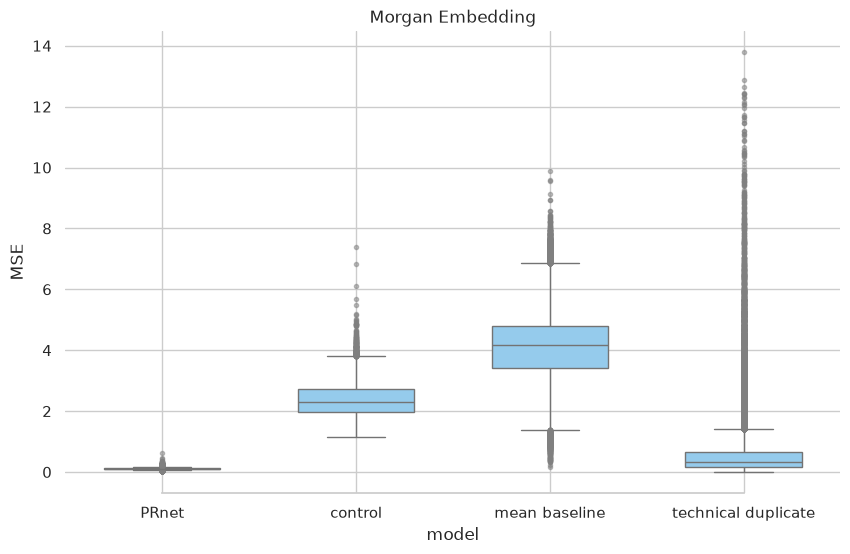

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

flier_styles = dict(
    marker='o',            
    markerfacecolor='grey',
    markeredgecolor='grey', 
    markersize=3,          
    alpha=0.5   
)           
sns.boxplot(
    smiles_agg, x="model", y="MSE",
    color= "lightskyblue", width=0.6, flierprops=flier_styles,
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="MSE", title= "Morgan Embedding")
sns.despine(trim=True, left=True)

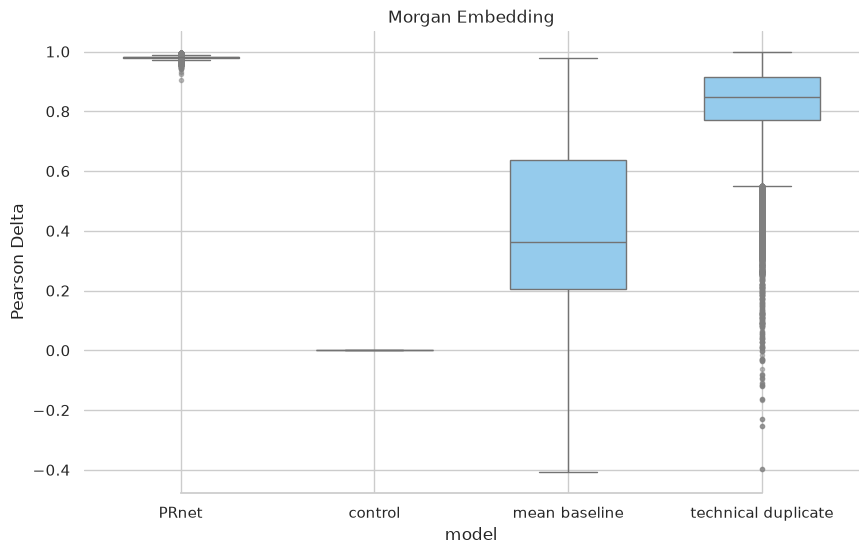

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    smiles_agg, x="model", y="Pearson Delta",
    color= "lightskyblue", width=.6, flierprops=flier_styles
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta", title= "Morgan Embedding")
sns.despine(trim=True, left=True)

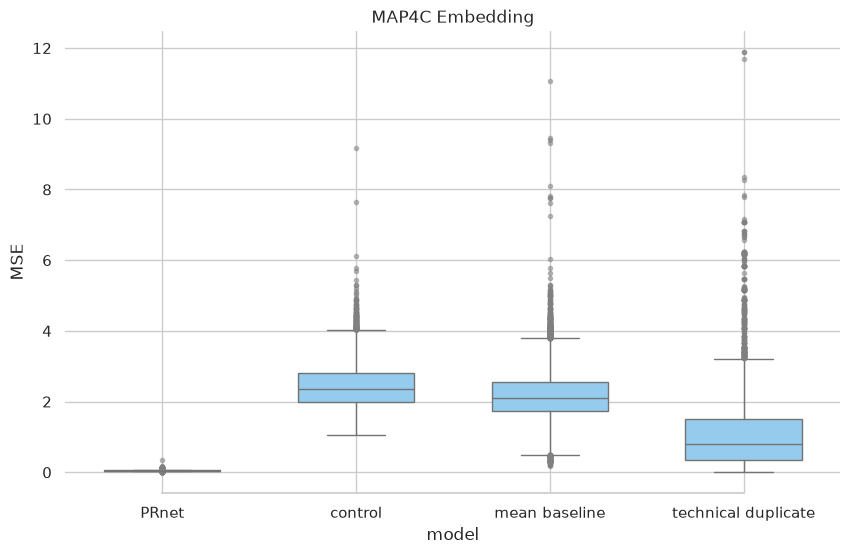

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    fp_agg, x="model", y="MSE",
    color= "lightskyblue", width=.6, flierprops=flier_styles
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="MSE", title= "MAP4C Embedding")
sns.despine(trim=True, left=True)

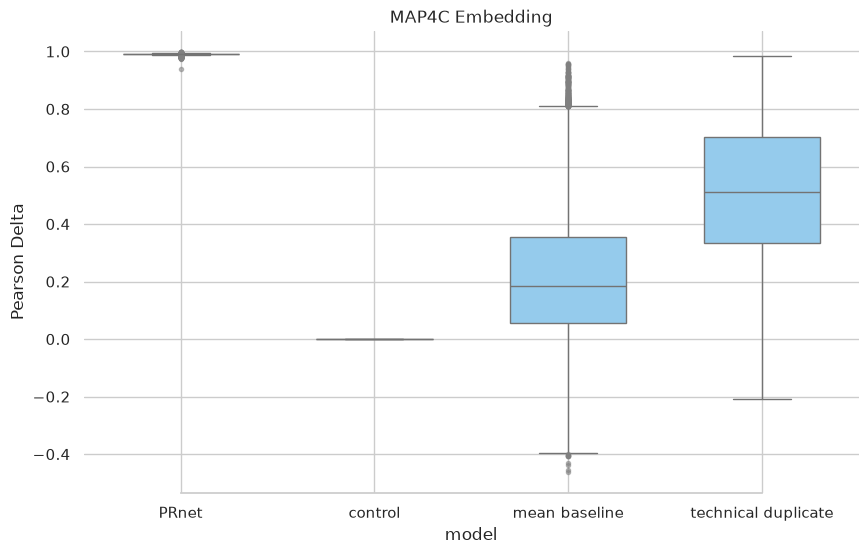

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    fp_agg, x="model", y="Pearson Delta",
    color= "lightskyblue", width=.6, flierprops=flier_styles
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta", title= "MAP4C Embedding")
sns.despine(trim=True, left=True)

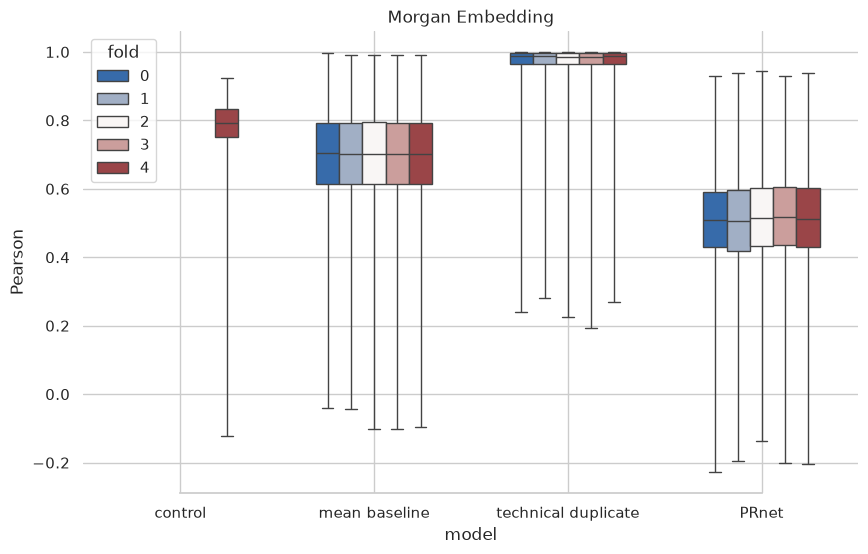

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

plot1_df = all_metrics_smiles
plot1_df["fold"] = plot1_df["fold"].astype(str).str.extract(r"(\d)\D*$").astype(int)

# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot1_df, x="model", y="Pearson", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson", title= "Morgan Embedding")
sns.despine(trim=True, left=True)

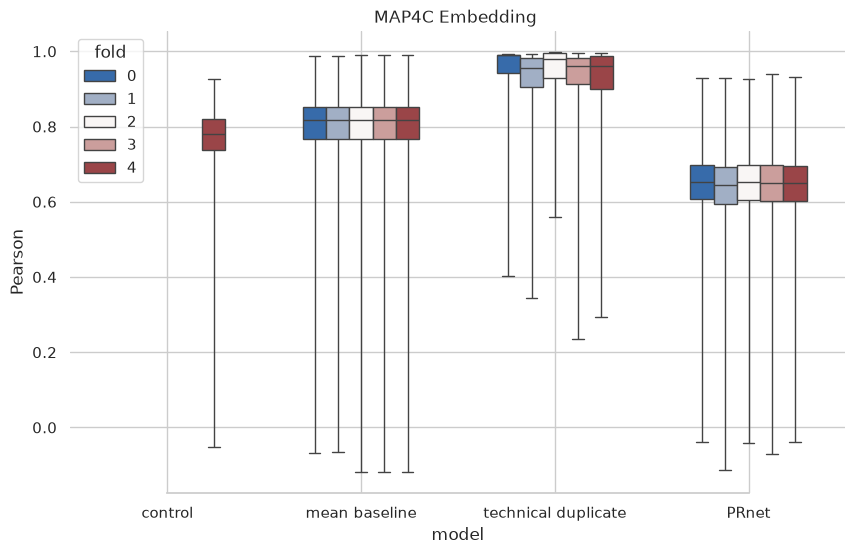

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

plot2_df = all_metrics_map4c
plot2_df["fold"] = plot2_df["fold"].astype(str).str.extract(r"(\d)\D*$").astype(int)

# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot2_df, x="model", y="Pearson", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson", title= "MAP4C Embedding ")
sns.despine(trim=True, left=True)

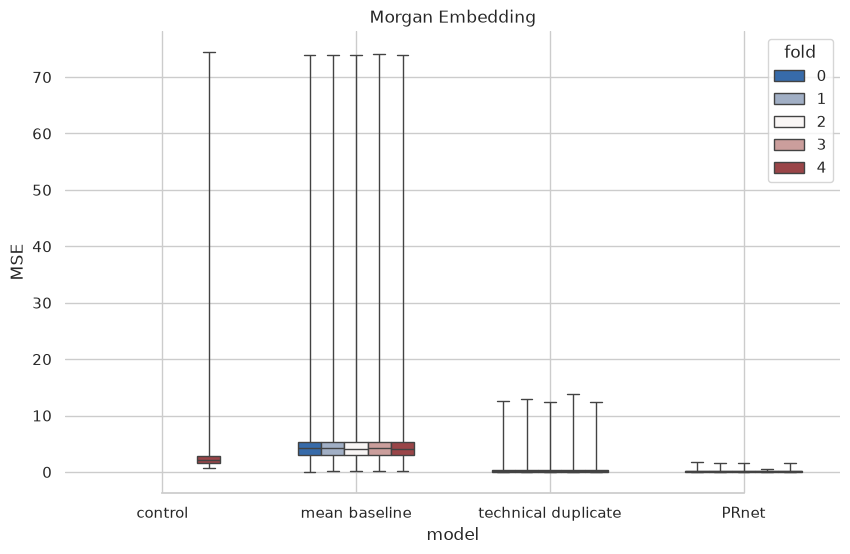

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot1_df, x="model", y="MSE", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="MSE", title="Morgan Embedding")
sns.despine(trim=True, left=True)

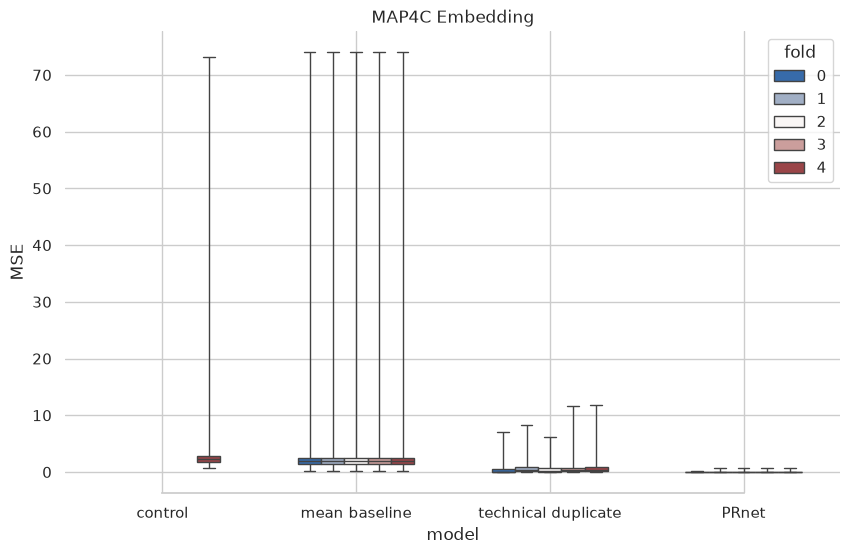

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot2_df, x="model", y="MSE", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="MSE", title="MAP4C Embedding")
sns.despine(trim=True, left=True)

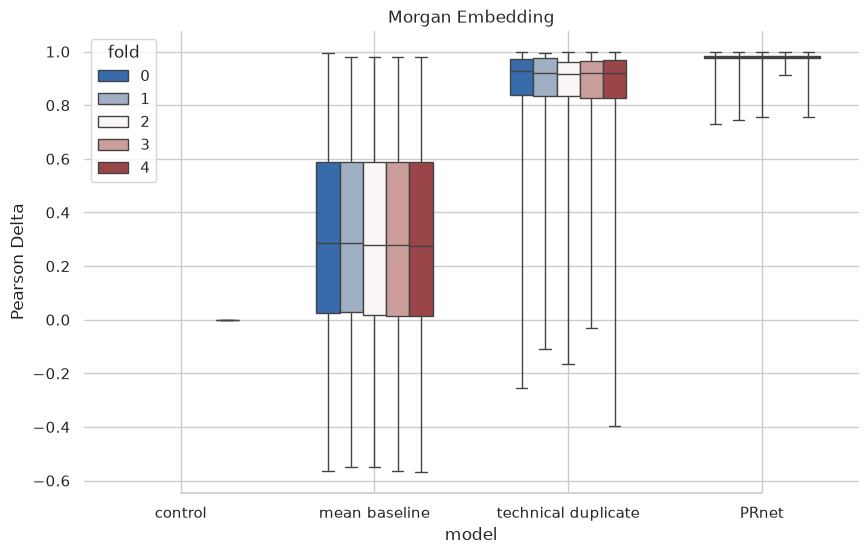

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot1_df, x="model", y="Pearson Delta", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta", title="Morgan Embedding")
sns.despine(trim=True, left=True)

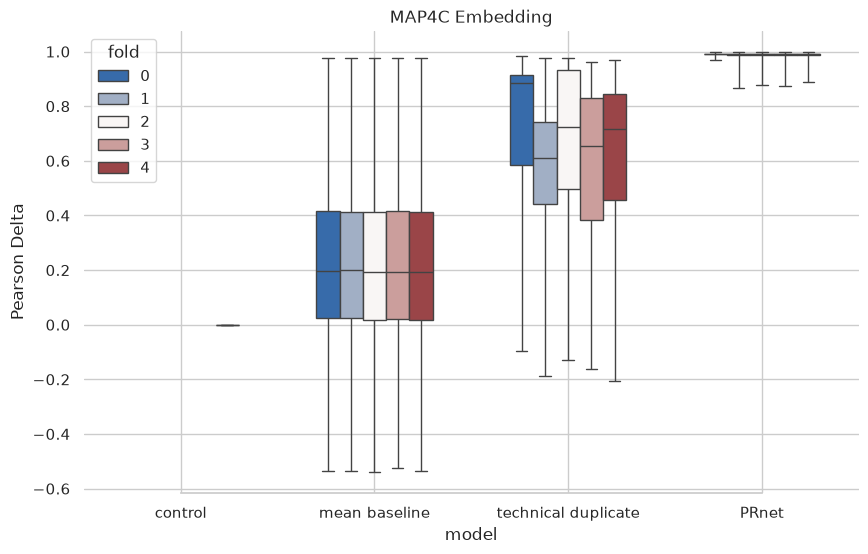

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))


# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot2_df, x="model", y="Pearson Delta", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta", title="MAP4C Embedding")
sns.despine(trim=True, left=True)

In [ ]:
models = {
    #"control": control_metrics,
    #"mean baseline": mean_bl_metrics_smiles,
    #"technical duplicate": td_metrics_smiles,
    "PRnet [Morgan Embedding]": smiles_metrics,
    "PRnet [MAP4C Embedding]": map4c_metrics
}

data_split_metrics_df = (
    pd.concat(models.values(), keys=models.keys(), names=["model", None])
    .reset_index(level="model")
    .reset_index(drop=True)
)

if "Unnamed: 0" in data_split_metrics_df.columns:
    data_split_metrics_df = data_split_metrics_df.rename(columns={"Unnamed: 0": "epoch"})

data_split_metrics_df


,model,fold,cov_drug,Pearson,Pearson Delta,MSE
0,PRnet [Morgan Embedding],canonical_smiles_split_0,HEPG2_BRD-K60230970,0.407667,0.967526,0.185378
1,PRnet [Morgan Embedding],canonical_smiles_split_0,PC3_BRD-K60230970,0.344459,0.976010,0.129686
2,PRnet [Morgan Embedding],canonical_smiles_split_0,MCF10A_BRD-K35629949,0.673403,0.988741,0.058496
3,PRnet [Morgan Embedding],canonical_smiles_split_0,PC3_BRD-K42091312,0.452231,0.973060,0.141751
4,PRnet [Morgan Embedding],canonical_smiles_split_0,VCAP_BRD-K11746559,0.707414,0.988369,0.065347
...,...,...,...,...,...,...
1456127,PRnet [MAP4C Embedding],canonical_smiles_split_4,PC3_BRD-K90826279,0.681149,0.990406,0.050256
1456128,PRnet [MAP4C Embedding],canonical_smiles_split_4,HCC515_BRD-K07572174,0.712809,0.992190,0.041472
1456129,PRnet [MAP4C Embedding],canonical_smiles_split_4,VCAP_BRD-K17896185,0.682160,0.990576,0.049120
1456130,PRnet [MAP4C Embedding],canonical_smiles_split_4,HUH7_BRD-K35468722,0.693618,0.992650,0.038669


In [ ]:
plot3_df = data_split_metrics_df
plot3_df["fold"] = plot3_df["fold"].astype(str).str.extract(r"(\d)\D*$").astype(int)

metrics = ["Pearson", "Pearson Delta", "MSE"]

comp_agg = plot3_df.groupby(["model", "cov_drug"])[metrics].mean()

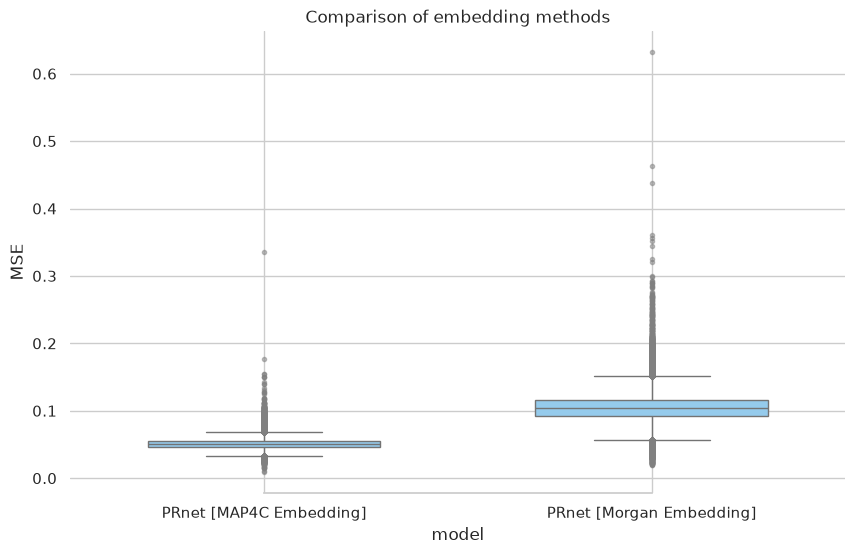

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    comp_agg, x="model", y="MSE",
    color= "lightskyblue", width=.6, flierprops=flier_styles
)

ax.xaxis.grid(True)
ax.set(ylabel="MSE", title= "Comparison of embedding methods")
sns.despine(trim=True, left=True)

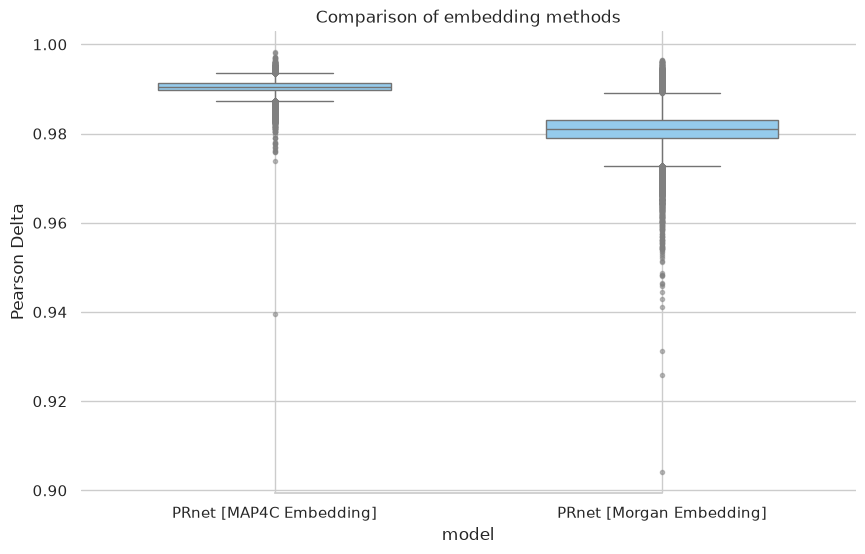

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    comp_agg, x="model", y="Pearson Delta",
    color= "lightskyblue", width=.6, flierprops=flier_styles
)

ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta", title= "Comparison of embedding methods")
sns.despine(trim=True, left=True)

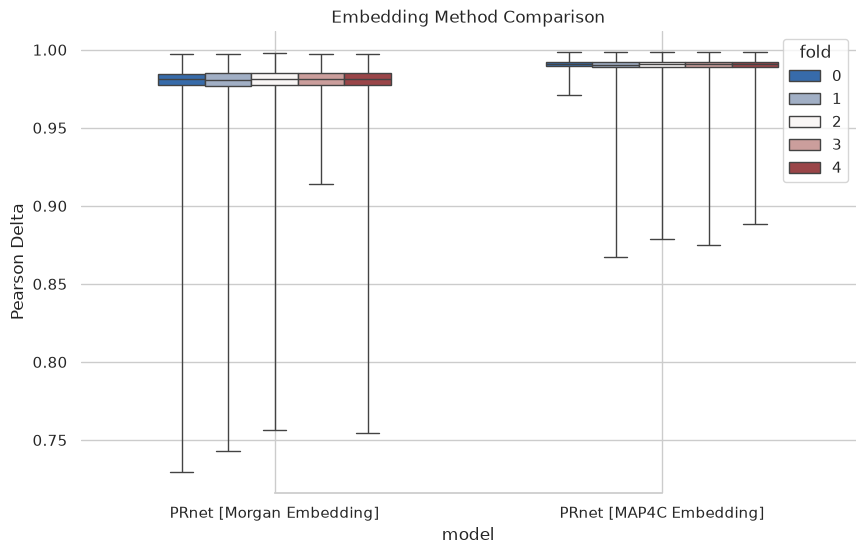

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

plot3_df = data_split_metrics_df
plot3_df["fold"] = plot3_df["fold"].astype(str).str.extract(r"(\d)\D*$").astype(int)

# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot3_df, x="model", y="Pearson Delta", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson Delta", title="Embedding Method Comparison")
sns.despine(trim=True, left=True)


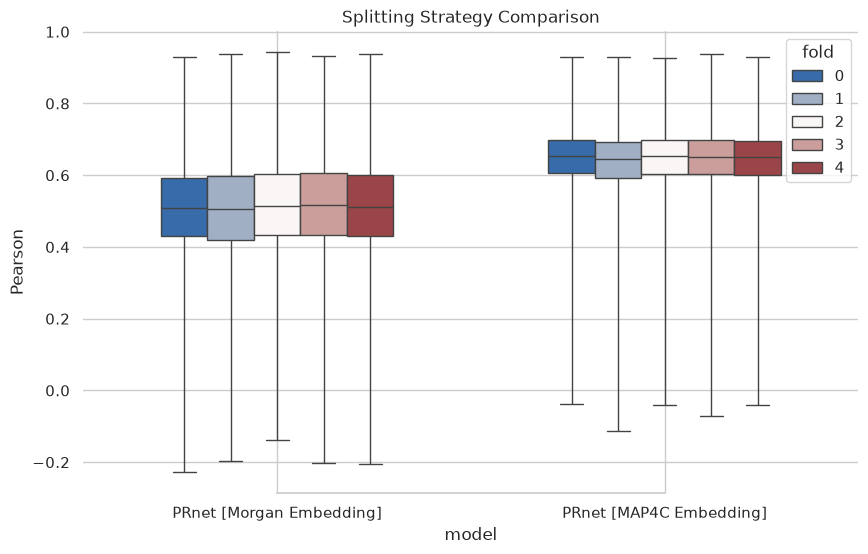

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

plot3_df = data_split_metrics_df
plot3_df["fold"] = plot3_df["fold"].astype(str).str.extract(r"(\d)\D*$").astype(int)

# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot3_df, x="model", y="Pearson", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Pearson", title="Splitting Strategy Comparison")
sns.despine(trim=True, left=True)

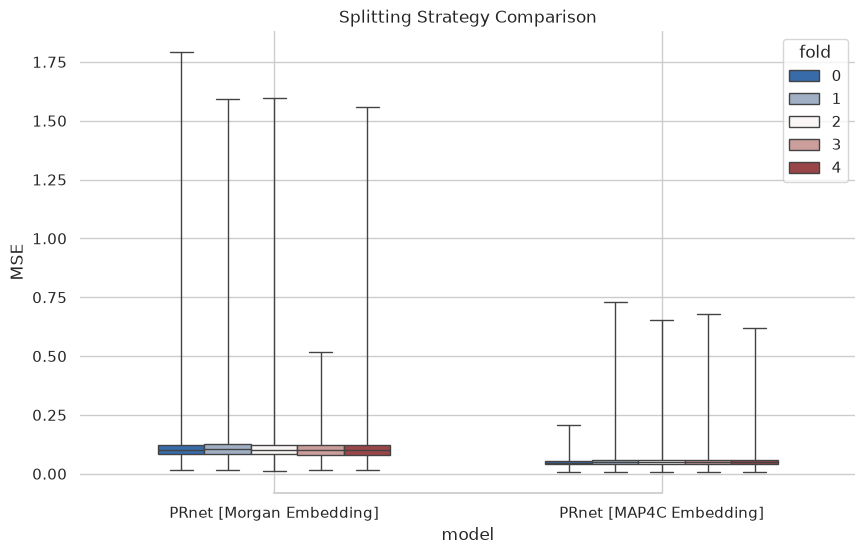

In [ ]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(10, 6))

plot3_df = data_split_metrics_df
plot3_df["fold"] = plot3_df["fold"].astype(str).str.extract(r"(\d)\D*$").astype(int)

# Plot the orbital period with horizontal boxes
sns.boxplot(
    plot3_df, x="model", y="MSE", hue="fold",
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="MSE", title="Splitting Strategy Comparison")
sns.despine(trim=True, left=True)

##### Examine which compounds make the most difference in performance

In [ ]:
# 1. Extract the raw Broad Drug ID from cov_drug
df = data_split_metrics_df
df["drug_id"] = df["cov_drug"].str.split("_").str[1]

# 2. Sort so SMILES and MAP4C match row-for-row per (cov_drug, fold)
df = df.sort_values(["fold", "cov_drug", "model"])

# 3. Calculate per-compound average Pearson difference between SMILES and MAP4c
compound_diffs = (
    df.groupby(["drug_id", "model"])["Pearson"]
    .mean()
    .unstack()  # Places SMILES and MAP4C into side-by-side columns
)

# 4. Compute the performance delta
compound_diffs["delta"] = (
    compound_diffs["PRnet [Morgan Embedding]"] - compound_diffs["PRnet [MAP4C Embedding]"]
)
compound_diffs["abs_delta"] = compound_diffs["delta"].abs()

In [ ]:
# Top compounds where SMILES won
top_smiles = compound_diffs.sort_values("delta", ascending=False).head(10)

# Top compounds where MAP4c won
top_map4c = compound_diffs.sort_values("delta", ascending=True).head(10)

# Top compounds with biggest overall divergence (in either direction)
top_divergent = compound_diffs.sort_values("abs_delta", ascending=False).head(
    10
)

In [ ]:
top_smiles

model,PRnet [MAP4C Embedding],PRnet [Morgan Embedding],delta,abs_delta
drug_id,,,,
BRD-K61779668,0.154026,0.895021,0.740995,0.740995
BRD-K90842913,0.163364,0.578418,0.415054,0.415054
BRD-K63521663,0.443256,0.788791,0.345535,0.345535
BRD-K68325500,0.478032,0.781753,0.303721,0.303721
BRD-K13517531,0.201312,0.501541,0.300229,0.300229
BRD-K98832554,0.355934,0.650407,0.294473,0.294473
BRD-K34407245,0.453054,0.746634,0.293580,0.293580
BRD-K20848134,0.643161,0.919947,0.276786,0.276786
BRD-K00998404,0.454520,0.723172,0.268653,0.268653


In [ ]:
top_map4c

model,PRnet [MAP4C Embedding],PRnet [Morgan Embedding],delta,abs_delta
drug_id,,,,
BRD-K35088115,0.642885,0.040783,-0.602101,0.602101
BRD-K77221985,0.650978,0.064938,-0.586040,0.586040
BRD-K88786596,0.777678,0.213538,-0.564140,0.564140
BRD-K63091163,0.629897,0.066738,-0.563159,0.563159
BRD-K40918107,0.775848,0.252916,-0.522932,0.522932
BRD-K43013792,0.727968,0.208396,-0.519571,0.519571
BRD-K78380066,0.763614,0.254016,-0.509598,0.509598
BRD-K07479774,0.679495,0.170361,-0.509134,0.509134
BRD-K97671879,0.803628,0.297738,-0.505890,0.505890


In [ ]:
top_divergent

model,PRnet [MAP4C Embedding],PRnet [Morgan Embedding],delta,abs_delta
drug_id,,,,
BRD-K61779668,0.154026,0.895021,0.740995,0.740995
BRD-K35088115,0.642885,0.040783,-0.602101,0.602101
BRD-K77221985,0.650978,0.064938,-0.586040,0.586040
BRD-K88786596,0.777678,0.213538,-0.564140,0.564140
BRD-K63091163,0.629897,0.066738,-0.563159,0.563159
BRD-K40918107,0.775848,0.252916,-0.522932,0.522932
BRD-K43013792,0.727968,0.208396,-0.519571,0.519571
BRD-K78380066,0.763614,0.254016,-0.509598,0.509598
BRD-K07479774,0.679495,0.170361,-0.509134,0.509134


##### Conduct Statistical Analyses

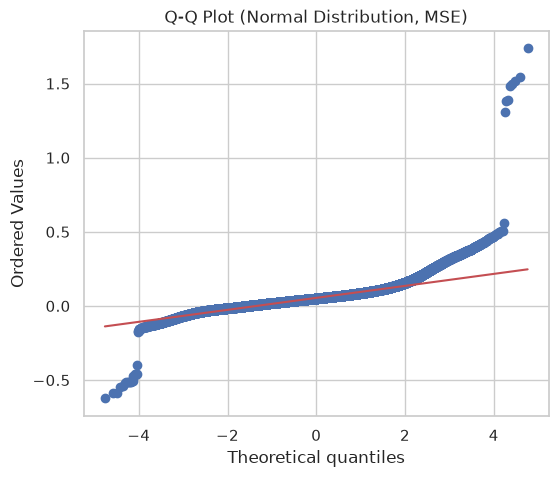

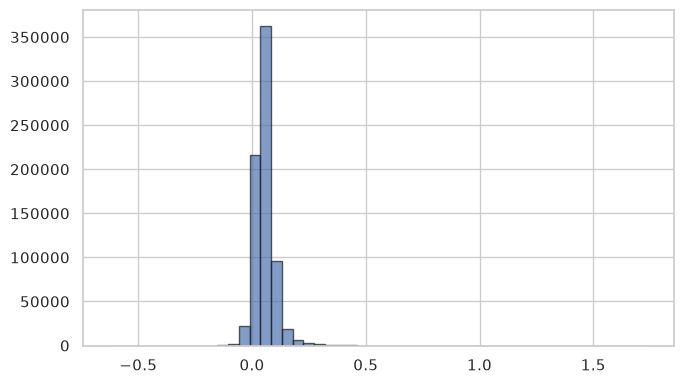

In [ ]:
smiles_df = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [Morgan Embedding]']
map4c_df     = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [MAP4C Embedding]']

mse_diff = smiles_df['MSE'].values - map4c_df['MSE'].values

plt.figure(figsize=(6, 5))
stats.probplot(mse_diff, dist="norm", plot=plt)

plt.title("Q-Q Plot (Normal Distribution, MSE)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(mse_diff, bins=50, edgecolor='k', alpha=0.7)
plt.tight_layout()
plt.show()

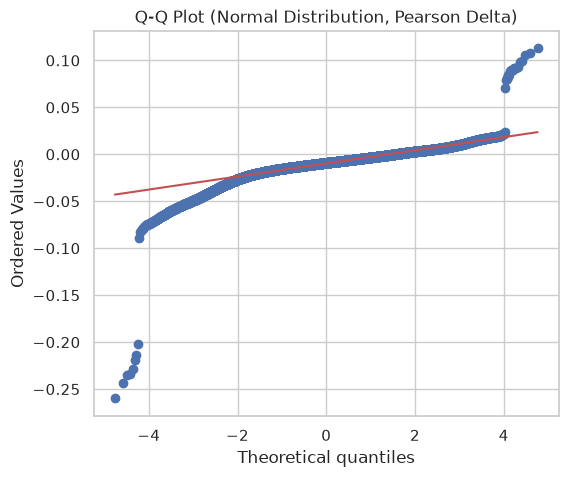

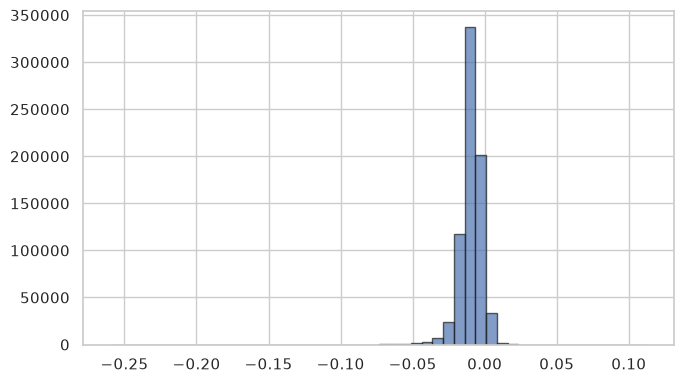

In [ ]:
smiles_df = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [Morgan Embedding]']
map4c_df     = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [MAP4C Embedding]']

mse_diff = smiles_df['Pearson Delta'].values - map4c_df['Pearson Delta'].values

#sm.qqplot(mse_diff, line ='45')
#py.show()

plt.figure(figsize=(6, 5))
stats.probplot(mse_diff, dist="norm", plot=plt)

plt.title("Q-Q Plot (Normal Distribution, Pearson Delta)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(mse_diff, bins=50, edgecolor='k', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
smiles_df

,model,fold,cov_drug,Pearson,Pearson Delta,MSE,drug_id
0,PRnet [Morgan Embedding],0,HEPG2_BRD-K60230970,0.407667,0.967526,0.185378,BRD-K60230970
1,PRnet [Morgan Embedding],0,PC3_BRD-K60230970,0.344459,0.976010,0.129686,BRD-K60230970
2,PRnet [Morgan Embedding],0,MCF10A_BRD-K35629949,0.673403,0.988741,0.058496,BRD-K35629949
3,PRnet [Morgan Embedding],0,PC3_BRD-K42091312,0.452231,0.973060,0.141751,BRD-K42091312
4,PRnet [Morgan Embedding],0,VCAP_BRD-K11746559,0.707414,0.988369,0.065347,BRD-K11746559
...,...,...,...,...,...,...,...
728061,PRnet [Morgan Embedding],4,PC3_BRD-K90826279,0.613234,0.984473,0.083107,BRD-K90826279
728062,PRnet [Morgan Embedding],4,HCC515_BRD-K07572174,0.431734,0.973739,0.141254,BRD-K07572174
728063,PRnet [Morgan Embedding],4,VCAP_BRD-K17896185,0.270927,0.974789,0.146887,BRD-K17896185
728064,PRnet [Morgan Embedding],4,HUH7_BRD-K35468722,0.238232,0.972114,0.156955,BRD-K35468722


In [ ]:
map4c_df

,model,fold,cov_drug,Pearson,Pearson Delta,MSE,drug_id
728066,PRnet [MAP4C Embedding],0,HEPG2_BRD-K60230970,0.703544,0.992648,0.038451,BRD-K60230970
728067,PRnet [MAP4C Embedding],0,PC3_BRD-K60230970,0.620906,0.991611,0.045468,BRD-K60230970
728068,PRnet [MAP4C Embedding],0,MCF10A_BRD-K35629949,0.725943,0.990464,0.049580,BRD-K35629949
728069,PRnet [MAP4C Embedding],0,PC3_BRD-K42091312,0.681314,0.991934,0.042421,BRD-K42091312
728070,PRnet [MAP4C Embedding],0,VCAP_BRD-K11746559,0.673777,0.991108,0.046583,BRD-K11746559
...,...,...,...,...,...,...,...
1456127,PRnet [MAP4C Embedding],4,PC3_BRD-K90826279,0.681149,0.990406,0.050256,BRD-K90826279
1456128,PRnet [MAP4C Embedding],4,HCC515_BRD-K07572174,0.712809,0.992190,0.041472,BRD-K07572174
1456129,PRnet [MAP4C Embedding],4,VCAP_BRD-K17896185,0.682160,0.990576,0.049120,BRD-K17896185
1456130,PRnet [MAP4C Embedding],4,HUH7_BRD-K35468722,0.693618,0.992650,0.038669,BRD-K35468722


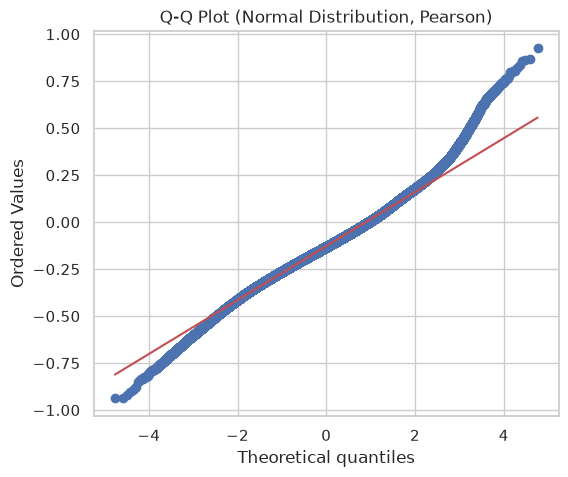

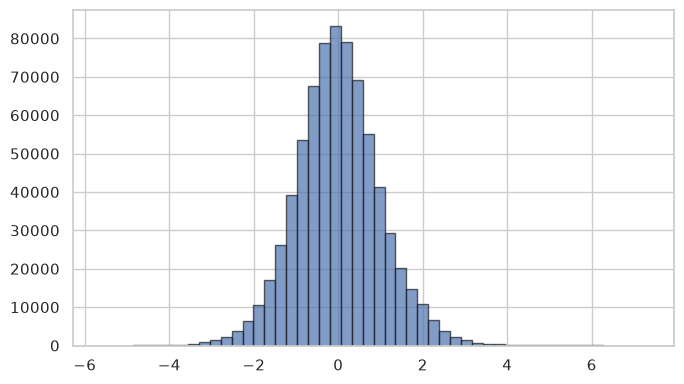

In [ ]:
smiles_df = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [Morgan Embedding]']
map4c_df     = data_split_metrics_df[data_split_metrics_df['model'] == 'PRnet [MAP4C Embedding]']

mse_diff = smiles_df['Pearson'].values - map4c_df['Pearson'].values
mse_diff_standard = (mse_diff - np.mean(mse_diff)) / np.std(mse_diff)

plt.figure(figsize=(6, 5))
stats.probplot(mse_diff, dist="norm", plot=plt)

plt.title("Q-Q Plot (Normal Distribution, Pearson)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(mse_diff_standard, bins=50, edgecolor='k', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
w_mse2 = ttest_rel(smiles_df['MSE'], map4c_df['MSE'], alternative='less')
w_mse_pvalue2 = w_mse2.pvalue

w_mse_pvalue2

np.float64(1.0)

: 

: 

: 

In [ ]:
cohen_d = pg.compute_effsize(smiles_df['MSE'], map4c_df['MSE'], paired=True, eftype='cohen')
cohen_d

np.float64(1.717558416432057)

: 

: 

: 

In [ ]:
w_pearson = wilcoxon(x=smiles_df['Pearson'], y=map4c_df['Pearson'], alternative='less')
w_pearson_pvalue = w_pearson.pvalue
w_pearson_pvalue

np.float64(0.0)

: 

: 

: 

In [ ]:
n = len(smiles_df['Pearson'])
max_w = n * (n + 1) / 2
rank_biserial = 1 - (2 * w_pearson.statistic / max_w)
rank_biserial

np.float64(0.7952902943820248)

: 

: 

: 

In [ ]:
w_pearson2 = ttest_rel(smiles_df['Pearson'], map4c_df['Pearson'], alternative='less')
w_pearson_pvalue2 = w_pearson2.pvalue


w_pearson_pvalue2

np.float64(0.0)

: 

: 

: 

In [ ]:
cohen_d = pg.compute_effsize(smiles_df['Pearson'], map4c_df['Pearson'], paired=True, eftype='cohen')
cohen_d

np.float64(-1.0899289746475909)

: 

: 

: 

In [ ]:
w_pearson_delta = wilcoxon(x=smiles_df['Pearson Delta'], y=map4c_df['Pearson Delta'], alternative='less')
w_pearson_delta_pvalue = w_pearson_delta.pvalue
w_pearson_delta_pvalue

np.float64(0.0)

: 

: 

: 

In [ ]:
n = len(smiles_df['Pearson Delta'])
max_w = n * (n + 1) / 2
rank_biserial = 1 - (2 * w_pearson_delta.statistic / max_w)
rank_biserial

np.float64(0.9684904763491975)

: 

: 

: 

In [ ]:
w_pearson_delta2 = ttest_rel(smiles_df['Pearson Delta'], map4c_df['Pearson Delta'], alternative='less')
w_pearson_delta_pvalue2 = w_pearson_delta2.pvalue
w_pearson_delta_pvalue2

np.float64(0.0)

: 

: 

: 

In [ ]:
cohen_d = pg.compute_effsize(smiles_df['Pearson Delta'], map4c_df['Pearson Delta'], paired=True, eftype='cohen')
cohen_d

np.float64(-1.771218920791106)

: 

: 

: 

In [ ]:
w_mse = wilcoxon(x=smiles_df['MSE'], y=map4c_df['MSE'])
w_mse_pvalue = w_mse.pvalue

w_pearson = wilcoxon(x=smiles_df['Pearson'], y=map4c_df['Pearson'])
w_pearson_pvalue = w_pearson.pvalue

w_pearson_delta = wilcoxon(x=smiles_df['Pearson Delta'], y=map4c_df['Pearson Delta'])
w_pearson_delta_pvalue = w_pearson_delta.pvalue

: 

: 

: 

In [ ]:
array = [w_mse_pvalue, w_pearson_pvalue, w_pearson_delta_pvalue]
array

[np.float64(0.0), np.float64(0.0), np.float64(0.0)]

: 

: 

: 

In [ ]:
n = len(smiles_df['MSE'])
max_w = n * (n + 1) / 2
rank_biserial_mse = 1 - (2 * w_mse.statistic / max_w)

n = len(smiles_df['Pearson'])
max_w = n * (n + 1) / 2
rank_biserial_pearson = 1 - (2 * w_pearson.statistic / max_w)

n = len(smiles_df['Pearson Delta'])
max_w = n * (n + 1) / 2
rank_biserial_pearsondelta = 1 - (2 * w_pearson_delta.statistic / max_w)

: 

: 

: 

In [ ]:
array = [rank_biserial_mse, rank_biserial_pearson, rank_biserial_pearsondelta]
array

[np.float64(0.9686413373721061),
 np.float64(0.7952902943820248),
 np.float64(0.9684904763491975)]

: 

: 

: 

In [ ]:
w_mse2 = ttest_rel(smiles_df['MSE'], map4c_df['MSE'])
w_mse_pvalue2 = w_mse2.pvalue

w_pearson2 = ttest_rel(smiles_df['Pearson'], map4c_df['Pearson'])
w_pearson_pvalue2 = w_pearson2.pvalue

w_pearson_delta2 = ttest_rel(smiles_df['Pearson Delta'], map4c_df['Pearson Delta'])
w_pearson_delta_pvalue2 = w_pearson_delta2.pvalue

: 

: 

: 

In [ ]:
array = [w_mse_pvalue2, w_pearson_pvalue2, w_pearson_delta_pvalue2]
array

[np.float64(0.0), np.float64(0.0), np.float64(0.0)]

: 

: 

: 

In [ ]:
cohen_d_mse = pg.compute_effsize(smiles_df['MSE'], map4c_df['MSE'], paired=True, eftype='cohen')
cohen_d_pearson = pg.compute_effsize(smiles_df['Pearson'], map4c_df['Pearson'], paired=True, eftype='cohen')
cohen_d_pearsondelta = pg.compute_effsize(smiles_df['Pearson Delta'], map4c_df['Pearson Delta'], paired=True, eftype='cohen')

: 

: 

: 

In [ ]:
array = [cohen_d_mse, cohen_d_pearson, cohen_d_pearsondelta]
array

[np.float64(1.717558416432057),
 np.float64(-1.0899289746475909),
 np.float64(-1.771218920791106)]

: 

: 

: 